In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import numpy as np
from rl4evrp.utils import evaluate_agent

import sys
from pathlib import Path

# Add framework to path
framework_path = Path.cwd()
sys.path.insert(0, str(framework_path))

# Import RL4EVRP framework
import rl4evrp as rl

print("✓ RL4EVRP framework imported successfully")


def prepare_instance(instance, battery_cap=None, tw_enabled=None, feature_names=None):
    """
    Return a modified copy of an instance for masking experiments.
    """
    inst = dict(instance)

    if battery_cap is not None:
        inst["battery_cap"] = float(battery_cap)

    if tw_enabled is not None:
        inst["tw_enabled"] = bool(tw_enabled)
        if not tw_enabled:
            n = inst["n_nodes"]
            time_horizon = float(inst.get("time_horizon", 1.0))
            inst["ready_times"] = np.zeros(n, dtype=np.float32)
            inst["due_times"] = np.full(n, time_horizon, dtype=np.float32)
            inst["service_times"] = np.zeros(n, dtype=np.float32)

    if feature_names is not None:
        inst["state_feature_names"] = list(feature_names)

    return inst


def collect_nn_masking(env_class, instance, battery_cap=None, tw_enabled=None, feature_names=None):
    """
    Run a simple nearest-neighbor policy on one instance and return
    feasible action count per step.
    """
    inst = prepare_instance(
        instance,
        battery_cap=battery_cap,
        tw_enabled=tw_enabled,
        feature_names=feature_names,
    )
    inst["reward_mode"] = "distance"

    env = env_class(inst, reward_mode="distance")
    env.reset()

    feasible_counts = []
    done = False

    while not done:
        vm = env._valid_mask()
        feasible_counts.append(int(vm.sum()))

        valid_nodes = np.where(vm)[0]
        if len(valid_nodes) == 0:
            break

        # nearest valid node heuristic
        action = valid_nodes[np.argmin(env.D[env.cur, valid_nodes])]
        _, _, done, _ = env.step(action)

    return feasible_counts


def collect_model_masking(model, run_episode_fn, instance, battery_cap=None, tw_enabled=None, feature_names=None):
    """
    Run a trained model on one instance and return feasible action count per step.
    """
    import torch

    inst = prepare_instance(
        instance,
        battery_cap=battery_cap,
        tw_enabled=tw_enabled,
        feature_names=feature_names,
    )
    inst["reward_mode"] = "distance"

    with torch.no_grad():
        _, _, _, _, _, _, env = run_episode_fn(model, inst, greedy=True)

    feasible_counts = [env.n - mc for mc in env.masked_counts]
    return feasible_counts


def interpolate_traces(traces, n_points=100):
    """
    Align variable-length traces to a fixed progress grid and compute mean/std.
    """
    norm = np.linspace(0, 1, n_points)
    interp = []

    for t in traces:
        if len(t) < 2:
            continue
        x = np.linspace(0, 1, len(t))
        interp.append(np.interp(norm, x, t))

    arr = np.array(interp)
    if len(arr) == 0:
        return norm * 100, np.zeros_like(norm), np.zeros_like(norm)

    return norm * 100, arr.mean(0), arr.std(0)


def run_battery_ablation(
    env_class,
    instances,
    model=None,
    run_episode_fn=None,
    feature_names=None,
    battery_caps=(100, 60, 40),
    n_instances=50,
    tw_enabled=False,
    output_path=None,
    title="Masking dynamics under different battery capacities",
    show=True,
):
    """
    Run masking analysis across battery capacities.

    Args:
        env_class: your EVRPEnv class
        instances: list of instance dicts
        model: optional trained model
        run_episode_fn: required if model is provided
        feature_names: optional feature_names for old checkpoints
        battery_caps: capacities to compare
        n_instances: number of instances to average over
        tw_enabled: whether to keep time windows active
        output_path: if provided, save figure
        title: plot title
        show: display figure inline in notebook
    """
    use_model = model is not None and run_episode_fn is not None

    print("Collecting masking data...")
    print(f"Using {'trained model' if use_model else 'nearest-neighbor baseline'}")
    print(f"Time windows enabled: {tw_enabled}")

    # CVRP-like baseline: effectively no battery binding
    print("  CVRP-like baseline (battery disabled)...")
    cvrp_traces = []
    for i in range(min(n_instances, len(instances))):
        if use_model:
            t = collect_model_masking(
                model, run_episode_fn, instances[i],
                battery_cap=99999.0,
                tw_enabled=tw_enabled,
                feature_names=feature_names,
            )
        else:
            t = collect_nn_masking(
                env_class, instances[i],
                battery_cap=99999.0,
                tw_enabled=tw_enabled,
                feature_names=feature_names,
            )
        cvrp_traces.append(t)

    # EVRP variants with different capacities
    evrp_results = {}
    for cap in battery_caps:
        print(f"  EVRP battery_cap={cap} ...")
        traces = []
        for i in range(min(n_instances, len(instances))):
            if use_model:
                t = collect_model_masking(
                    model, run_episode_fn, instances[i],
                    battery_cap=cap,
                    tw_enabled=tw_enabled,
                    feature_names=feature_names,
                )
            else:
                t = collect_nn_masking(
                    env_class, instances[i],
                    battery_cap=cap,
                    tw_enabled=tw_enabled,
                    feature_names=feature_names,
                )
            traces.append(t)
        evrp_results[cap] = traces

    # Plot
    colors_evrp = {
        100: "#2ecc71",
        80: "#27ae60",
        60: "#f39c12",
        50: "#e67e22",
        40: "#c0392b",
        30: "#962d22",
    }
    markers_evrp = {
        100: "s", 80: "p", 60: "^", 50: "v", 40: "D", 30: "h",
    }

    fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))

    # CVRP-like baseline
    x, m, s = interpolate_traces(cvrp_traces)
    ax.plot(
        x, m,
        color="#3498db",
        linewidth=2.5,
        label="CVRP-like (battery disabled)",
        marker="o",
        markevery=10,
        markersize=6,
        ls="--",
        zorder=4,
    )
    ax.fill_between(x, m - s, m + s, color="#3498db", alpha=0.1, zorder=2)

    # EVRP curves
    for cap in sorted(evrp_results.keys(), reverse=True):
        traces = evrp_results[cap]
        color = colors_evrp.get(cap, "#888888")
        marker = markers_evrp.get(cap, "o")
        x, m, s = interpolate_traces(traces)

        ax.plot(
            x, m,
            color=color,
            linewidth=2.5,
            label=f"EVRP (cap={cap})",
            marker=marker,
            markevery=10,
            markersize=6,
            zorder=4,
        )
        ax.fill_between(x, m - s, m + s, color=color, alpha=0.1, zorder=2)

    ax.set_xlabel("Route progress (%)", fontsize=13)
    ax.set_ylabel("Feasible action set size", fontsize=13)
    ax.set_xlim(0, 100)
    ax.set_ylim(bottom=0)
    ax.grid(axis="both", alpha=0.15)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=10, loc="upper right", framealpha=0.9, edgecolor="#cccccc")
    ax.set_title(title, fontsize=13, fontweight="bold")

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved to {output_path}")

    if show:
        plt.show()
    else:
        plt.close()

    # Print summary
    print("\nSummary:")
    print(f"{'Config':<30} {'Final feasible':>15} {'Min feasible':>15}")
    print("-" * 65)

    x, m, _ = interpolate_traces(cvrp_traces)
    print(f"{'CVRP-like (battery disabled)':<30} {m[-1]:>15.1f} {m.min():>15.1f}")

    for cap in sorted(evrp_results.keys(), reverse=True):
        x, m, _ = interpolate_traces(evrp_results[cap])
        print(f"{f'EVRP (cap={cap})':<30} {m[-1]:>15.1f} {m.min():>15.1f}")

    return {
        "cvrp_like": cvrp_traces,
        "evrp": evrp_results,
    }

✓ RL4EVRP framework imported successfully


In [4]:
from rl4evrp.agents import A2CAgent
import rl4evrp.agents as agent_mod
import rl4evrp.models as models_mod

from rl4evrp.agents import A2CAgent
from rl4evrp.models import EVRPEncoder, EVRPDecoder

def load_model_adaptive(model_path):
    framework = rl.RL4EVRP()

    state_dict = torch.load(model_path, map_location="cpu")
    in_dim = state_dict["encoder.embed.weight"].shape[1]
    ctx_dim = state_dict["decoder.proj_ctx.weight"].shape[1]

    print("Checkpoint signature:")
    print(f"  encoder input dim = {in_dim}")
    print(f"  decoder ctx dim   = {ctx_dim}")

    framework.read_yaml("problem")
    framework.read_yaml("model")
    framework.read_yaml("env")

    if in_dim == 7 and ctx_dim == 130:
        feature_names = [
            "x",
            "y",
            "demand_normalized",
            "is_charger",
            "is_depot",
            "cargo_capacity_norm",
            "battery_capacity_norm",
        ]
        use_time_context = False

    elif in_dim == 10 and ctx_dim == 131:
        feature_names = [
            "x",
            "y",
            "demand_normalized",
            "is_charger",
            "is_depot",
            "cargo_capacity_norm",
            "battery_capacity_norm",
            "tw_ready_norm",
            "tw_due_norm",
            "service_time_norm",
        ]
        use_time_context = True

    else:
        raise ValueError(
            f"Unsupported checkpoint signature: input_dim={in_dim}, ctx_dim={ctx_dim}"
        )

    # Build model directly using the agent class
    model = A2CAgent(
        input_dim=in_dim,
        embed_dim=128,
        n_heads=8,
        n_layers=3,
        enc_type="gat",
        device=str(framework.device),
        use_time_context=use_time_context,
    )

    print("Current model signature:")
    print(f"  encoder.embed.weight = {tuple(model.encoder.embed.weight.shape)}")
    print(f"  decoder.proj_ctx.weight = {tuple(model.decoder.proj_ctx.weight.shape)}")

    model.load_state_dict(state_dict)
    model.to(framework.device)
    model.eval()

    return framework, model, feature_names


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_in

✓ Device: cpu
✓ Output directory: results_xai
Checkpoint signature:
  encoder input dim = 7
  decoder ctx dim   = 130
Current model signature:
  encoder.embed.weight = (128, 7)
  decoder.proj_ctx.weight = (128, 130)
Using trained model
Time windows enabled: False
  CVRP-like baseline (battery disabled)...
  EVRP battery_cap=100 ...
  EVRP battery_cap=60 ...
  EVRP battery_cap=40 ...
Saved to masking_battery_model.png


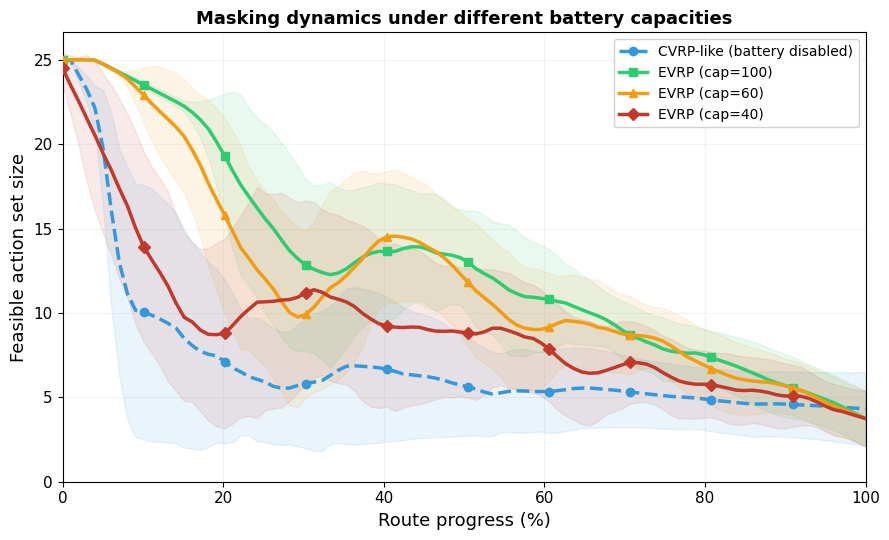


Summary:
Config                          Final feasible    Min feasible
-----------------------------------------------------------------
CVRP-like (battery disabled)               4.3             4.3
EVRP (cap=100)                             3.7             3.7
EVRP (cap=60)                              3.7             3.7
EVRP (cap=40)                              3.7             3.7


In [10]:
from rl4evrp.environment import EVRPEnv
from rl4evrp.utils import run_episode

from rl4evrp.environment import EVRPEnv



framework, model, feature_names = load_model_adaptive("agent_episode_100000.pt")
seed = 42
instances = [framework.generate_instance(seed=i) for i in range(50)]


results = run_battery_ablation(
    env_class=EVRPEnv,
    instances=instances,
    model=model,
    run_episode_fn=run_episode,
    feature_names=feature_names,   # important for old checkpoints
    battery_caps=[100, 60, 40],
    n_instances=50,
    tw_enabled=False,
    output_path="masking_battery_model.png",
    show=True,
)

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def interpolate_traces(traces, n_points=100):
    """
    Align variable-length traces to a fixed progress grid and compute mean/std.
    """
    norm = np.linspace(0, 1, n_points)
    interp = []

    for t in traces:
        if len(t) < 2:
            continue
        x = np.linspace(0, 1, len(t))
        interp.append(np.interp(norm, x, t))

    arr = np.array(interp)
    if len(arr) == 0:
        return norm * 100, np.zeros_like(norm), np.zeros_like(norm)

    return norm * 100, arr.mean(0), arr.std(0)


def plot_masking_dynamics_variants(
    traces_by_variant,
    output_path=None,
    show=True,
    annotate=True,
):
    """
    Plot masking dynamics in the style of your example.

    Args:
        traces_by_variant: dict like
            {
              "CVRP": [...],
              "EVRP": [...],
              "CVRPTW": [...],
              "EVRPTW": [...],
            }
        output_path: optional path to save figure
        show: whether to display figure
        annotate: whether to add explanatory annotations
    """
    style = {
        "CVRP":   {"color": "#3498db", "marker": "o"},
        "EVRP":   {"color": "#27ae60", "marker": "s"},
        "CVRPTW": {"color": "#f39c12", "marker": "^"},
        "EVRPTW": {"color": "#c0392b", "marker": "D"},
    }

    order = ["CVRP", "EVRP", "CVRPTW", "EVRPTW"]

    fig, ax = plt.subplots(figsize=(8.6, 5.2))

    for variant in order:
        if variant not in traces_by_variant:
            continue

        x, m, s = interpolate_traces(traces_by_variant[variant])
        color = style[variant]["color"]
        marker = style[variant]["marker"]

        ax.plot(
            x, m,
            color=color,
            linewidth=2.4,
            marker=marker,
            markevery=10,
            markersize=5.5,
            label=variant,
            zorder=4,
        )
        ax.fill_between(
            x, m - s, m + s,
            color=color,
            alpha=0.12,
            zorder=2,
        )

    ax.set_xlabel("Route progress (%)", fontsize=15)
    ax.set_ylabel(r"Feasible actions  $|A_{\mathrm{feas}}|$", fontsize=15)
    ax.set_xlim(0, 100)
    ax.set_ylim(bottom=0)
    ax.grid(axis="both", alpha=0.15)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=11, loc="upper right", framealpha=0.95)

    if annotate:
        ax.annotate(
            "Time windows\nnarrow early",
            xy=(18, 12.2),
            xytext=(10, 6.8),
            color="#f39c12",
            fontsize=11,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#f39c12", lw=1.5),
        )

        ax.annotate(
            "Battery constraint\nactivates",
            xy=(64, 7.8),
            xytext=(42, 4.0),
            color="#27ae60",
            fontsize=11,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#27ae60", lw=1.5),
        )

        ax.annotate(
            "Combined pressure:\nbattery + TW",
            xy=(74, 3.6),
            xytext=(55, 1.0),
            color="#c0392b",
            fontsize=11,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.5),
        )

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved figure to {output_path}")

    if show:
        plt.show()
    else:
        plt.close()

    return fig

In [12]:
def prepare_instance_for_variant(instance, variant, feature_names=None):
    """
    Create a modified copy of one base instance to emulate a routing variant.
    """
    inst = dict(instance)

    if variant == "CVRP":
        inst["charger_prob"] = 0.0
        inst["tw_enabled"] = False
        inst["battery_cap"] = 99999.0
        n = inst["n_nodes"]
        time_horizon = float(inst.get("time_horizon", 1.0))
        inst["ready_times"] = np.zeros(n, dtype=np.float32)
        inst["due_times"] = np.full(n, time_horizon, dtype=np.float32)
        inst["service_times"] = np.zeros(n, dtype=np.float32)

    elif variant == "EVRP":
        inst["tw_enabled"] = False
        n = inst["n_nodes"]
        time_horizon = float(inst.get("time_horizon", 1.0))
        inst["ready_times"] = np.zeros(n, dtype=np.float32)
        inst["due_times"] = np.full(n, time_horizon, dtype=np.float32)
        inst["service_times"] = np.zeros(n, dtype=np.float32)

    elif variant == "CVRPTW":
        inst["battery_cap"] = 99999.0
        inst["tw_enabled"] = True

    elif variant == "EVRPTW":
        inst["tw_enabled"] = True

    else:
        raise ValueError(f"Unknown variant: {variant}")

    if feature_names is not None:
        inst["state_feature_names"] = list(feature_names)

    return inst

In [15]:
def collect_masking_traces_by_variant(
    instances,
    variants=("CVRP", "EVRP", "CVRPTW", "EVRPTW"),
    model=None,
    run_episode_fn=None,
    env_class=None,
    feature_names=None,
    n_instances=100,
):
    """
    Collect masking traces for each variant.
    If model is given, uses the trained policy.
    Otherwise uses nearest-neighbor fallback.
    """
    traces_by_variant = {v: [] for v in variants}
    use_model = model is not None and run_episode_fn is not None

    for variant in variants:
        print(f"Collecting traces for {variant}...")

        for i in range(min(n_instances, len(instances))):
            inst = prepare_instance_for_variant(instances[i], variant, feature_names=feature_names)
            inst["reward_mode"] = "distance"

            if use_model:
                import torch
                with torch.no_grad():
                    _, _, _, _, _, _, env = run_episode_fn(model, inst, greedy=True)
                feasible_counts = [env.n - mc for mc in env.masked_counts]
            else:
                env = env_class(inst, reward_mode="distance")
                env.reset()
                feasible_counts = []
                done = False

                while not done:
                    vm = env._valid_mask()
                    feasible_counts.append(int(vm.sum()))
                    valid_nodes = np.where(vm)[0]
                    if len(valid_nodes) == 0:
                        break
                    action = valid_nodes[np.argmin(env.D[env.cur, valid_nodes])]
                    _, _, done, _ = env.step(action)

            traces_by_variant[variant].append(feasible_counts)

    return traces_by_variant

✓ Device: cpu
✓ Output directory: results_xai
Checkpoint signature:
  encoder input dim = 7
  decoder ctx dim   = 130
Current model signature:
  encoder.embed.weight = (128, 7)
  decoder.proj_ctx.weight = (128, 130)
Saved figure to masking_dynamics_variants.png


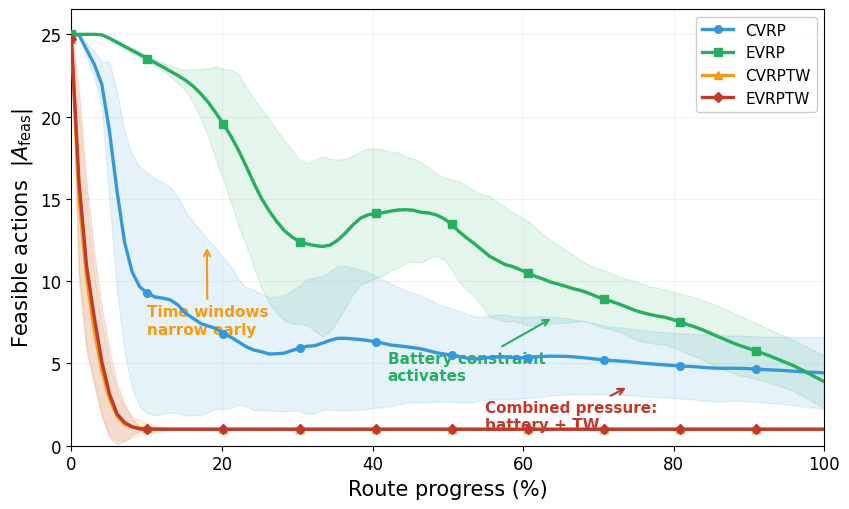

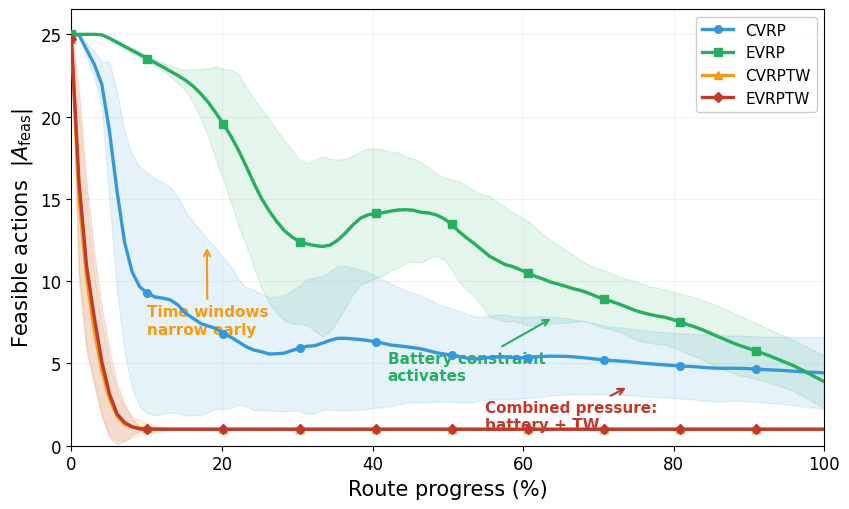

In [16]:
from rl4evrp.environment import EVRPEnv
from rl4evrp.utils import run_episode


framework, model, feature_names = load_model_adaptive("agent_episode_100000.pt")
seed = 42

instances = [framework.generate_instance(seed=i) for i in range(100)]

traces_by_variant = collect_masking_traces_by_variant(
    instances=instances,
    variants=("CVRP", "EVRP", "CVRPTW", "EVRPTW"),
    model=model,
    run_episode_fn=run_episode,
    feature_names=feature_names,   # use this for old checkpoints
    n_instances=100,
)

plot_masking_dynamics_variants(
    traces_by_variant,
    output_path="masking_dynamics_variants.png",
    show=True,
)